In [174]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# Set the path to the file you'd like to load
file_path = "./data.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "starblasters8/human-vs-llm-text-corpus",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:                                                 text    source  prompt_id  \
0  Federal law supersedes state law, and cannabis...  Bloom-7B          0   
1  Miles feels restless after working all day. He...  Bloom-7B          0   
2  So first of I am danish. That means that I fol...  Bloom-7B          0   
3  In this paper we present a novel rule-based ap...  Bloom-7B          0   
4  Most social progressives, love democracy, and ...  Bloom-7B          0   

   text_length  word_count  
0          967         157  
1         5068         778  
2         1602         267  
3         5469         848  
4         2379         380  


In [65]:
df.shape

(788922, 5)

In [66]:
df.columns

Index(['text', 'source', 'prompt_id', 'text_length', 'word_count'], dtype='object')

In [67]:
df

,text,source,prompt_id,text_length,word_count
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380
...,...,...,...,...,...
788917,"\nIn the vast expanse of time, where the echoe...",YI-34B,1293,5523,870
788918,"\nThe phenomenon of brain drain, particularly ...",YI-34B,1154,4540,677
788919,\nThe Influence of Climate Change on Marine Ec...,YI-34B,2783,3889,598
788920,\nTitle: The Case for Limiting Car Usage: Navi...,YI-34B,41,3560,533


In [68]:
(df["text"] == "").sum()

np.int64(0)

In [69]:
(df["source"] == "").sum()

np.int64(0)

In [70]:
df.isna().sum()

text           0
source         0
prompt_id      0
text_length    0
word_count     0
dtype: int64

In [71]:
df.isin(["NA", "null", "?", "unknown"]).sum()

text           0
source         0
prompt_id      0
text_length    0
word_count     0
dtype: int64

In [72]:
df["source"].unique()

array(['Bloom-7B', 'Claude-Instant-v1', 'Claude-v1', 'Cohere-Command',
       'Dolphin-2.5-Mixtral-8x7B', 'Dolphin-Mixtral-8x7B', 'Falcon-180B',
       'Flan-T5-Base', 'Flan-T5-Large', 'Flan-T5-Small', 'Flan-T5-XL',
       'Flan-T5-XXL', 'GLM-130B', 'GPT-3.5', 'GPT-4', 'GPT-J', 'GPT-NeoX',
       'Gemini-Pro', 'Goliath-120B', 'Human', 'LLaMA-13B', 'LLaMA-2-70B',
       'LLaMA-2-7B', 'LLaMA-30B', 'LLaMA-65B', 'LLaMA-7B', 'LZLV-70B',
       'Mistral-7B', 'Mistral-7B-OpenOrca', 'Mixtral-8x7B',
       'MythoMax-L2-13B', 'Neural-Chat-7B', 'Noromaid-20B',
       'Nous-Capybara-34B', 'Nous-Capybara-7B', 'Nous-Hermes-LLaMA-2-13B',
       'Nous-Hermes-LLaMA-2-70B', 'OPT-1.3B', 'OPT-125M', 'OPT-13B',
       'OPT-2.7B', 'OPT-30B', 'OPT-350M', 'OPT-6.7B', 'OpenChat-3.5',
       'OpenHermes-2-Mistral-7B', 'OpenHermes-2.5-Mistral-7B', 'PaLM-2',
       'Psyfighter-13B', 'Psyfighter-2-13B', 'RWKV-5-World-3B',
       'StripedHyena-Nous-7B', 'T0-11B', 'T0-3B', 'Text-Ada-001',
       'Text-Babbage-001', 

In [138]:
df_mod = df.copy().drop(columns=["source", "prompt_id"]) # removed prompt_id since most text data wont have prompt info
df_mod["ai_generated"] = df["source"].apply(lambda x: 0 if x == "Human" else 1)

In [139]:
df_mod.groupby("ai_generated")["text"].count() / df.shape[0] * 100
# 44% Human
# 56% AI

ai_generated
0    44.071784
1    55.928216
Name: text, dtype: float64

In [140]:
df[df_mod["text"].duplicated()] # check for duplicates

,text,source,prompt_id,text_length,word_count


In [141]:
df_train, df_test = train_test_split(df_mod, test_size=0.2, random_state=42, shuffle=True, stratify=df_mod["ai_generated"])

In [142]:
df_train

,text,text_length,word_count,ai_generated
261272,Analysis of Blood System’s Sides Essay\n\nThe ...,2363,344,0
640311,"In May 2013, ABC launched ""WATCH ABC,"" a revam...",2528,400,1
629386,Wireless Sensor Networks (WSNs) with their dyn...,7444,887,1
308309,Ethereal qualities and sexuality in art: Aphro...,3730,604,0
132676,"In the annals of human exploration, the final ...",4207,656,1
...,...,...,...,...
568134,"\n\nBiochar, a carbon-rich product derived fro...",5124,728,1
426570,Tracking what food you eat and when you get a ...,276,46,0
230281,Social and Criminal Justice Responses to Sex W...,16592,2569,0
508602,""" I just want to be different. Special, you kn...",2153,447,1


In [143]:
df_test

,text,text_length,word_count,ai_generated
190624,Completing the Doctor of Nursing Practice Proj...,6794,1013,0
232502,@ashleycyw \nHi there. I see that you're new ...,1034,179,0
171030,"It's for the University of Texas, what do you ...",3828,659,0
525716,I think this place was pretty good. I'm an eas...,992,192,1
737188,Every morning a man ran down Phil's street at ...,358,70,1
...,...,...,...,...
648499,Fifty sheep were stolen from a farm in Ammanfo...,2080,354,1
466442,Blue whales have also been known to protect se...,989,168,0
297932,"""Describe the world you come from, and tell us...",2987,501,0
637417,"Granted, I went to this pool on a weekday...ho...",882,155,1


In [145]:
df_train.groupby("ai_generated")["text"].count() / df_train.shape[0] * 100

ai_generated
0    44.071731
1    55.928269
Name: text, dtype: float64

In [146]:
df_test.groupby("ai_generated")["text"].count() / df_test.shape[0] * 100

ai_generated
0    44.071997
1    55.928003
Name: text, dtype: float64

In [147]:
df_train[["text_length", "word_count"]].describe(include=np.number)

,text_length,word_count
count,631137.000000,631137.000000
mean,3120.432100,497.464281
std,4978.114595,719.054638
min,105.000000,25.000000
25%,646.000000,110.000000
50%,1918.000000,323.000000
75%,3908.000000,624.000000
max,890119.000000,71543.000000


In [148]:
df_train.groupby("ai_generated")[["text_length", "word_count"]].describe(include=np.number)

text_length                                                  \
                   count         mean          std    min    25%     50%   
ai_generated                                                               
0               278153.0  4468.529061  7014.091060  110.0  891.0  2282.0   
1               352984.0  2058.125552  1726.648571  105.0  493.0  1662.0   

                               word_count                                 \
                 75%       max      count        mean          std   min   
ai_generated                                                               
0             5410.0  890119.0   278153.0  709.361114  1000.701789  25.0   
1             3419.0   54288.0   352984.0  330.488611   268.509270  25.0   

                                            
                25%    50%    75%      max  
ai_generated                                
0             152.0  395.0  882.0  71543.0  
1              86.0  277.0  535.0   9418.0

In [122]:
df_train[df_train["text_length"] >= 300000] # There are big outliers, but they are informative -> Human Generated Text

,text,source,prompt_id,text_length,word_count
305807,Nursing Care of Autistic Children Essay\n\nSum...,0,0,374560,20368
304308,Water Management: Soft-Path Approach in Abu Dh...,0,0,300188,38665
180018,Islamic Law: E-Sale Contracts Essay\n\nIntrodu...,0,0,366131,60636
259052,China’s Publicly Listed Companies’ Financial M...,0,0,315600,21906
227088,E-Sale Contract From an Islamic Perspective Es...,0,0,432950,71543
228796,Occupational Stress in the Maritime Industry C...,0,0,343904,56005
191180,Paper Recycling: Environmental and Business Is...,0,0,890119,20083


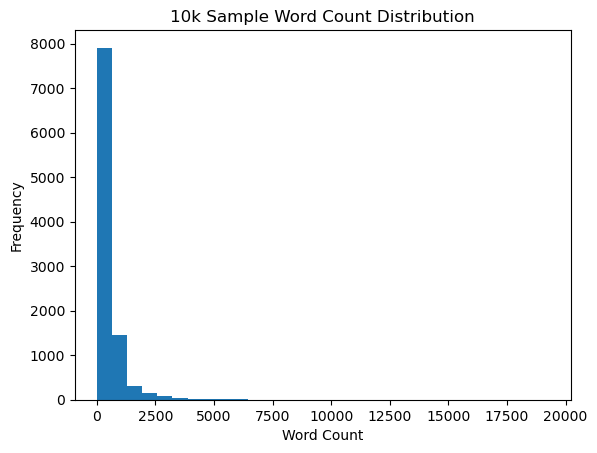

In [201]:
sample = df_train["word_count"].sample(10000) # Take 10000 to sample

plt.hist(sample, bins=30)
plt.title("10k Sample Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.savefig("./figs/word_count_hist.png")
plt.show()

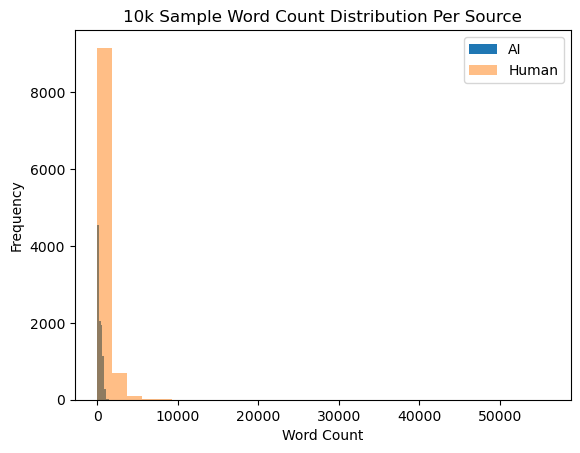

In [202]:
ai = df_train[df_train["ai_generated"] == 1]["word_count"].sample(10000)
human = df_train[df_train["ai_generated"] == 0]["word_count"].sample(10000)

plt.hist(ai, bins=30, label="AI")
plt.hist(human, bins=30, alpha=0.5, label="Human")
plt.title("10k Sample Word Count Distribution Per Source")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("./figs/word_count_hist_by_class.png")
plt.show()

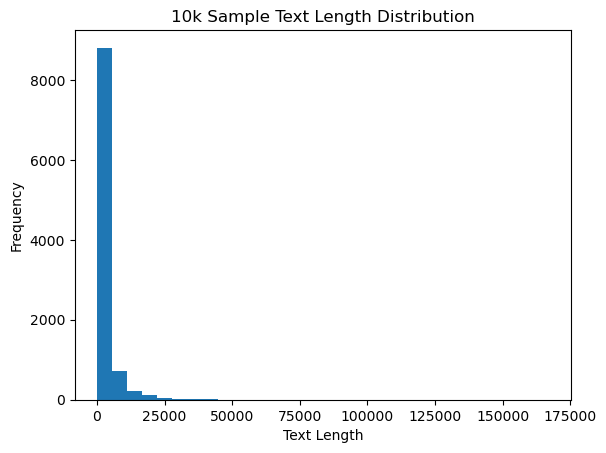

In [203]:
sample = df_train["text_length"].sample(10000) # Take 10000 to sample

plt.hist(sample, bins=30)
plt.title("10k Sample Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.savefig("./figs/text_length_hist.png")
plt.show()

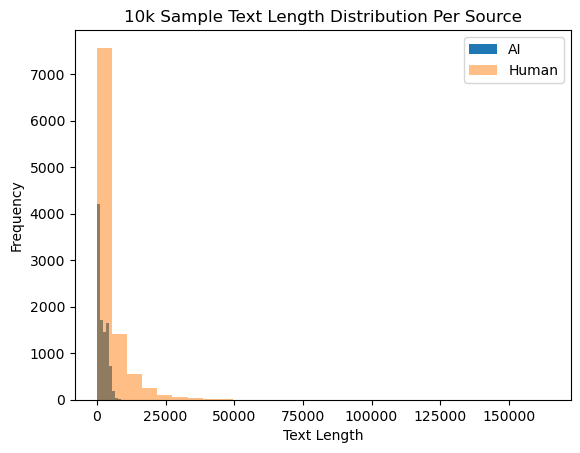

In [204]:
ai = df_train[df_train["ai_generated"] == 1]["text_length"].sample(10000)
human = df_train[df_train["ai_generated"] == 0]["text_length"].sample(10000)

plt.hist(ai, bins=30, label="AI")
plt.hist(human, bins=30, alpha=0.5, label="Human")
plt.title("10k Sample Text Length Distribution Per Source")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("./figs/text_length_hist_by_class.png")
plt.show()

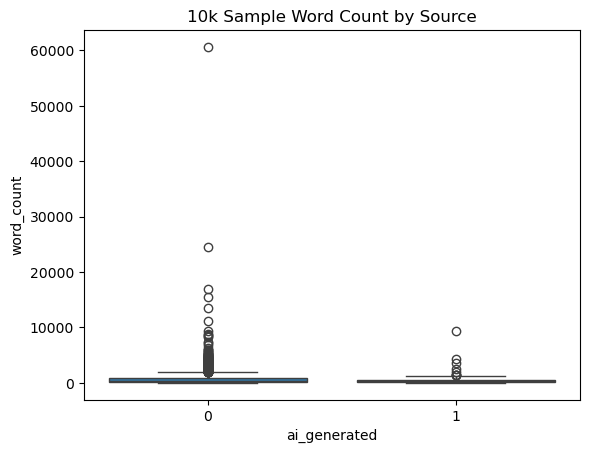

In [208]:
sns.boxplot(data=df_train.sample(10000), x="ai_generated", y="word_count")

plt.title("10k Sample Word Count by Source")
plt.savefig("./figs/word_count_by_class.png")
plt.show()

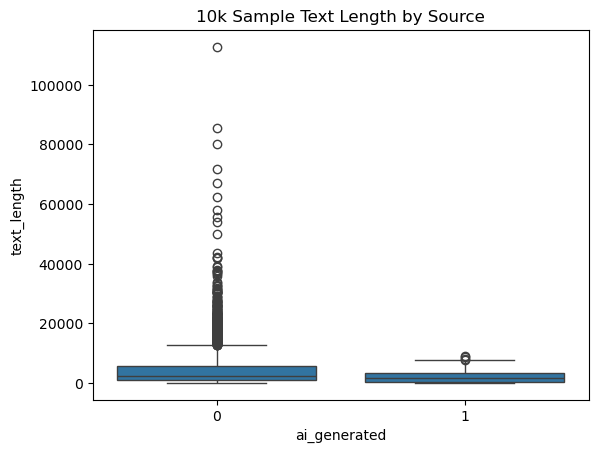

In [209]:
sns.boxplot(data=df_train.sample(10000), x="ai_generated", y="text_length")

plt.title("10k Sample Text Length by Source")
plt.savefig("./figs/text_length_by_class.png")
plt.show()

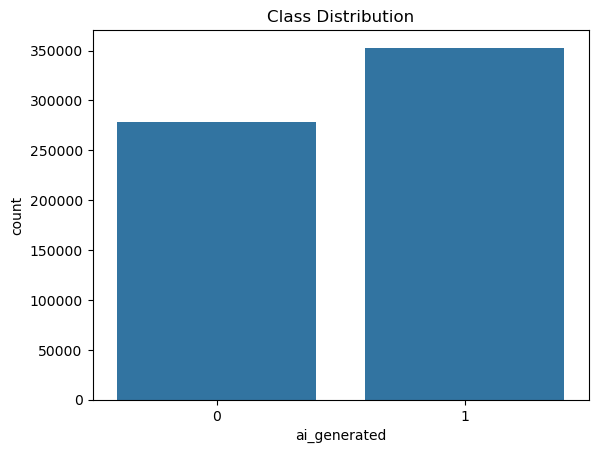

In [207]:
sns.countplot(data=df_train, x="ai_generated")

plt.title("Class Distribution")
plt.savefig("./figs/class_dist.png")
plt.show()

In [198]:
df_train.to_csv('./data/train.csv', index=False)
df_test.to_csv('./data/test.csv', index=False)